In [1]:
import numpy as np
import pandas as pd
import copy
import time
import os
import random

import seaborn as sns
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    f1_score
)

from scipy.ndimage import median_filter

from tqdm import tqdm

import warnings
warnings.filterwarnings("ignore")

In [2]:
DATA_PATH = "/kaggle/input/datasets/karans01/taekwondo-kinematic/extracted_csvs"
AUGMENTED_DATA_PATH = "/kaggle/input/datasets/karans01/taekwondo-kinematic/augmented_csvs"

TARGET_KICKS = ["frontkick", "roundhouse", "sidekick"]

MAX_FRAMES = 325

BATCH_SIZE = 16
EPOCHS = 50
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-5

TEST_SIZE = 0.15
N_FOLDS = 5

PATIENCE = 10


DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
SEED=42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [4]:
FEATURE_COLUMNS = [
    "base_knee_angle",
    "base_pivot_angle",
    "striking_chamber_angle",
    "striking_foot_angle",
    "spine_angle",
    "striking_ankle_y",
    "base_ankle_y",
    "guard_dropped"
]


CONTINUOUS_COLUMNS = [
    "base_knee_angle",
    "base_pivot_angle",
    "striking_chamber_angle",
    "striking_foot_angle",
    "spine_angle",
    "striking_ankle_y",
    "base_ankle_y"
]


NODE_FEATURES = {
    0: ["base_knee_angle", "base_pivot_angle"],
    1: ["striking_chamber_angle", "striking_foot_angle"],
    2: ["spine_angle", "guard_dropped"],
    3: ["striking_ankle_y", "base_ankle_y"]
}

MASTER_MAP = {

    "frontkick": {
        "frontkick_perfect": 0,
        "frontkick_errorDroppedGuard": 1,
        "frontkick_errorLeaningBack": 2,
        "frontkick_errorNoChamber": 3,
        "frontkick_errorNoRetraction": 4,
    },

    "roundhouse": {
        "roundhouse_perfect": 0,
        "roundhouse_errorDroppedGuard": 1,
        "roundhouse_errorLazyChamber": 2,
    },

    "sidekick": {
        "sidekick_perfect": 0,
        "sidekick_errorDroppedGuard": 1,
        "sidekick_errorFootPointingUp": 2,
        "sidekick_errorNoPivot": 3,
        "sidekick_errorOffBalance": 4,
    }
}

In [9]:
def add_meta_data(data_dir):
    rows = []
    for filename in os.listdir(data_dir):
        if not filename.endswith(".csv"):
            continue
        df = pd.read_csv(os.path.join(data_dir, filename))
        parts = filename.split("_")
        kick = parts[0]
        execution = parts[1]
        rows.append({
            "file": filename,
            "kick": kick,
            "execution": execution,
            "frames": len(df)
        })

    return pd.DataFrame(rows)

In [10]:
summary_df = add_meta_data(DATA_PATH)

print("Total original videos:", len(summary_df))

display(
    summary_df.groupby(["kick", "execution"]).agg(
        videos=("file", "count"),
        min_frames=("frames", "min"),
        max_frames=("frames", "max"),
        mean_frames=("frames", "mean")
    )
)

Total original videos: 142


videos  min_frames  max_frames  mean_frames
kick       execution                                                       
frontkick  controlled                9          42         124    87.000000
           errorDroppedGuard         9          31          91    62.222222
           errorLeaningBack          8          28          70    47.375000
           errorNoChamber            9          42          64    55.333333
           errorNoRetraction         9          50          69    60.111111
           perfect                   9          59          79    68.444444
roundhouse controlled                8          57         280   140.000000
           errorDroppedGuard         9          41         110    81.777778
           errorLazyChamber          9          49          92    68.111111
           perfect                   9          33         103    63.555556
sidekick   controlled                9         118         173   141.777778
           errorDroppedGuard         9          30          73    45.777778
           errorFootPointingUp       9          61         101    77.333333
           errorNoPivot              9          84          93    88.444444
           errorOffBalance           9          34         131    62.777778
           perfect                   9          66          89    78.111111

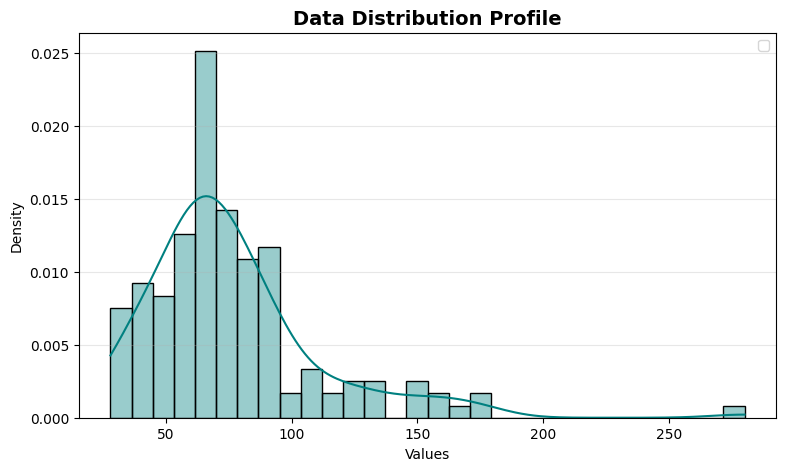

In [11]:
plt.figure(figsize=(9, 5))

sns.histplot(summary_df['frames'], kde=True, color="teal", stat="density", alpha=0.4, bins=30)

plt.title(f'Data Distribution Profile', fontsize=14, fontweight='bold')
plt.xlabel('Values')
plt.ylabel('Density')
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.show()

In [12]:
def clean_sequence(df, median_kernel=5):
    df = df.copy()
    df[FEATURE_COLUMNS] = df[FEATURE_COLUMNS].astype(np.float32)

    df[FEATURE_COLUMNS] = df[FEATURE_COLUMNS].interpolate(method="linear",limit_direction="both")

    for col in CONTINUOUS_COLUMNS:
        df[col] = median_filter(df[col].to_numpy(),size=median_kernel,mode="nearest")

    df["guard_dropped"] = df["guard_dropped"].rolling(window=5,min_periods=1,center=True).median().round().clip(0, 1)
    
    return df


sample = os.path.join(DATA_PATH,"sidekick_perfect_01_cam45.csv")
df_raw = pd.read_csv(sample)

df_clean = clean_sequence(df_raw)

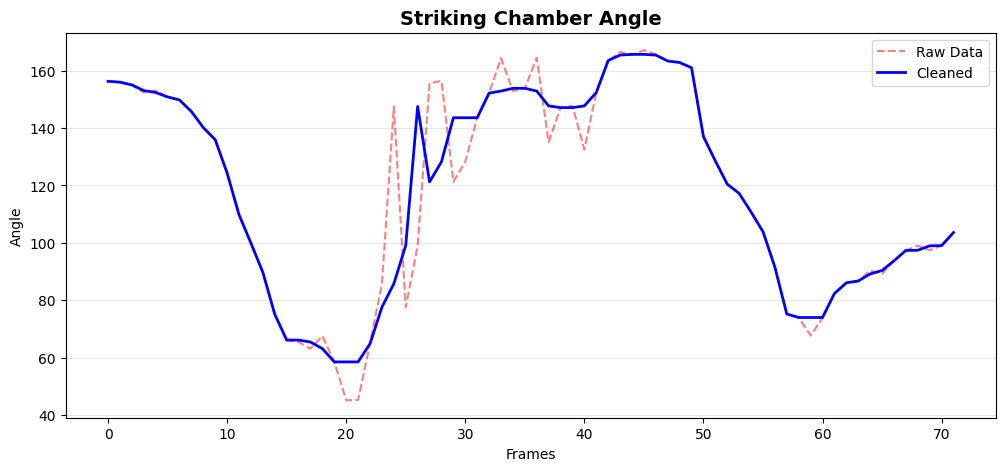

In [13]:
plt.figure(figsize=(12, 5))
plt.plot(df_raw['striking_chamber_angle'], label='Raw Data', color='red', alpha=0.5, linestyle='--')
plt.plot(df_clean['striking_chamber_angle'], label='Cleaned', color='blue', linewidth=2)

plt.title('Striking Chamber Angle', fontsize=14, fontweight='bold')
plt.xlabel('Frames')
plt.ylabel('Angle')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

In [14]:
def build_manifest(data_path):
    records = []
    for filename in sorted(os.listdir(data_path)):
        parts = filename.split("_")

        kick = parts[0]
        execution = parts[1]

        if execution == "controlled":
            execution = "perfect"

        class_name = f"{kick}_{execution}"

        records.append({
            "filename": filename,
            "base_video": filename,
            "kick": kick,
            "class_name": class_name,
            "label": MASTER_MAP[kick][class_name]
        })

    return pd.DataFrame(records)


manifest = build_manifest(DATA_PATH)

print("Total original videos:", len(manifest))
manifest.groupby(["kick", "class_name"]).size().to_frame("count")

Total original videos: 142


count
kick       class_name                         
frontkick  frontkick_errorDroppedGuard       9
           frontkick_errorLeaningBack        8
           frontkick_errorNoChamber          9
           frontkick_errorNoRetraction       9
           frontkick_perfect                18
roundhouse roundhouse_errorDroppedGuard      9
           roundhouse_errorLazyChamber       9
           roundhouse_perfect               17
sidekick   sidekick_errorDroppedGuard        9
           sidekick_errorFootPointingUp      9
           sidekick_errorNoPivot             9
           sidekick_errorOffBalance          9
           sidekick_perfect                 18

In [15]:
manifest.head()

,filename,base_video,kick,class_name,label
0,frontkick_controlled_01_cam45.csv,frontkick_controlled_01_cam45.csv,frontkick,frontkick_perfect,0
1,frontkick_controlled_01_camFront.csv,frontkick_controlled_01_camFront.csv,frontkick,frontkick_perfect,0
2,frontkick_controlled_01_camSide.csv,frontkick_controlled_01_camSide.csv,frontkick,frontkick_perfect,0
3,frontkick_controlled_02_cam45.csv,frontkick_controlled_02_cam45.csv,frontkick,frontkick_perfect,0
4,frontkick_controlled_02_camFront.csv,frontkick_controlled_02_camFront.csv,frontkick,frontkick_perfect,0


In [16]:
AUG_SUFFIXES = [
    "_original.csv",
    "_noisy.csv",
    "_warped.csv",
    "_noisy_warped.csv"
]


def get_augmented_files(original_filename):
    extracted_name = original_filename[:-4]

    candidates = [
        f"{extracted_name}_original.csv",
        f"{extracted_name}_noisy.csv",
        f"{extracted_name}_warped.csv",
        f"{extracted_name}_noisy_warped.csv",
    ]

    augmented_files = []
    for filename in candidates:
        path = os.path.join(AUGMENTED_DATA_PATH,filename)
        augmented_files.append(path)

    return augmented_files

#=================================================================================================================================================================
augmentation_counts = []
for filename in manifest["filename"]:
    files = get_augmented_files(filename)
    augmentation_counts.append({
        "filename": filename,
        "augmentation_count": len(files)
    })

augmentation_check = pd.DataFrame(augmentation_counts)

augmentation_check["augmentation_count"].value_counts()
#=================================================================================================================================================================

augmentation_count
4    142
Name: count, dtype: int64

In [17]:
def create_test_split(manifest,test_size=0.15,seed=42):
    train_dev_parts = []
    test_parts = []

    for kick, kick_df in manifest.groupby("kick"):
        train_dev, test = train_test_split(kick_df,test_size=test_size,random_state=seed,stratify=kick_df["class_name"])
        train_dev_parts.append(train_dev)
        test_parts.append(test)

    train_dev_df = pd.concat(train_dev_parts).sample(frac=1, random_state=seed).reset_index(drop=True)
    test_df = pd.concat(test_parts).sample(frac=1, random_state=seed).reset_index(drop=True)

    return train_dev_df, test_df

In [18]:
train_dev_manifest, test_manifest = create_test_split(manifest,test_size=TEST_SIZE,seed=SEED)

print("Development videos:", len(train_dev_manifest))
print("Test videos:", len(test_manifest))

Development videos: 119
Test videos: 23


In [19]:
train_dev_manifest.groupby(["kick", "class_name"]).size().to_frame("count")

count
kick       class_name                         
frontkick  frontkick_errorDroppedGuard       8
           frontkick_errorLeaningBack        7
           frontkick_errorNoChamber          8
           frontkick_errorNoRetraction       7
           frontkick_perfect                15
roundhouse roundhouse_errorDroppedGuard      7
           roundhouse_errorLazyChamber       8
           roundhouse_perfect               14
sidekick   sidekick_errorDroppedGuard        7
           sidekick_errorFootPointingUp      8
           sidekick_errorNoPivot             7
           sidekick_errorOffBalance          8
           sidekick_perfect                 15

In [20]:
test_manifest.groupby(["kick", "class_name"]).size().to_frame("count")

count
kick       class_name                         
frontkick  frontkick_errorDroppedGuard       1
           frontkick_errorLeaningBack        1
           frontkick_errorNoChamber          1
           frontkick_errorNoRetraction       2
           frontkick_perfect                 3
roundhouse roundhouse_errorDroppedGuard      2
           roundhouse_errorLazyChamber       1
           roundhouse_perfect                3
sidekick   sidekick_errorDroppedGuard        2
           sidekick_errorFootPointingUp      1
           sidekick_errorNoPivot             2
           sidekick_errorOffBalance          1
           sidekick_perfect                  3

In [21]:
def create_folds(df, n_splits=5, seed=42):
    df = df.copy().reset_index(drop=True)

    df["group"] = df["base_video"]

    splitter = StratifiedGroupKFold(n_splits=n_splits,shuffle=True,random_state=seed)

    folds = []
    for fold, (train_idx, val_idx) in enumerate(
        splitter.split(df,y=df["class_name"],groups=df["group"]), start=1
    ):

        train_df = df.iloc[train_idx]
        val_df = df.iloc[val_idx]

        folds.append({
            "fold": fold,
            "train": train_df,
            "val": val_df
        })

    return folds

In [22]:
sidekick_dev = train_dev_manifest[train_dev_manifest["kick"] == "sidekick"].reset_index(drop=True)

sidekick_folds = create_folds(sidekick_dev,n_splits=5,seed=SEED)

for fold_data in sidekick_folds:
    print(
        f"Fold {fold_data['fold']}: "
        f"train={len(fold_data['train'])}, "
        f"val={len(fold_data['val'])}"
    )

Fold 1: train=36, val=9
Fold 2: train=35, val=10
Fold 3: train=36, val=9
Fold 4: train=36, val=9
Fold 5: train=37, val=8


In [23]:
def expand_training_manifest(train_manifest):

    rows = []
    for _, row in train_manifest.iterrows():
        original_filename = row["filename"]
        augmented_files = get_augmented_files(
            original_filename
        )
        
        for path in augmented_files:
            rows.append({
                "path": path,
                "filename": os.path.basename(path),
                "base_video": original_filename,
                "kick": row["kick"],
                "class_name": row["class_name"],
                "label": row["label"]
            })

    return pd.DataFrame(rows)

In [24]:
def calculate_mean_std(train_files):

    sums = np.zeros(len(FEATURE_COLUMNS), dtype=np.float64)
    squared_sums = np.zeros(len(FEATURE_COLUMNS), dtype=np.float64)

    count = 0
    for path in tqdm(train_files,desc="Calculating normalization"):

        df = pd.read_csv(path)

        values = df[FEATURE_COLUMNS].values.astype(np.float64)

        sums += values.sum(axis=0)
        squared_sums += (values ** 2).sum(axis=0)

        count += len(values)

    mean = sums / count

    variance = (squared_sums / count) - mean ** 2
    variance = np.maximum(variance, 1e-8)

    std = np.sqrt(variance)

    return mean.astype(np.float32), std.astype(np.float32)

In [25]:
class TaekwondoDataset(Dataset):

    def __init__(self,df,max_frames=325,mean=None,std=None):
        self.df = df.reset_index(drop=True)
        self.max_frames = max_frames
        self.mean = (
            np.asarray(mean, dtype=np.float32)
            if mean is not None
            else None
        )

        self.std = (
            np.asarray(std, dtype=np.float32)
            if std is not None
            else None
        )

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        
        row = self.df.iloc[idx]
        
        df = pd.read_csv(row["path"])

        values = df[FEATURE_COLUMNS].values.astype(np.float32)

        current_len = values.shape[0]

        if self.mean is not None:
            values = (values - self.mean) / self.std

        # Data Stored:
        #
        # 0 base_knee
        # 1 base_pivot
        # 2 chamber
        # 3 foot
        # 4 spine
        # 5 striking_ankle_y
        # 6 base_ankle_y
        # 7 guard
        #
        # Graph:
        #
        # Node 0 = base knee + base pivot
        # Node 1 = chamber + foot
        # Node 2 = spine + guard
        # Node 3 = striking ankle + base ankle

        values = values[:,[0, 1, 2, 3, 4, 7, 5, 6]]

        if current_len < self.max_frames:
            padding_length = self.max_frames - current_len
            last_frame = values[-1:]
            
            padding = np.repeat(last_frame,padding_length,axis=0)
            values = np.vstack([values, padding])

        elif current_len > self.max_frames:
            values = values[:self.max_frames]
            current_len = self.max_frames

        # [T, 4, 2] -> [C, T, V] 
        values = values.reshape(self.max_frames,4,2)
        values = np.transpose(values,(2, 0, 1))

        x = torch.tensor(values,dtype=torch.float32)
        y = torch.tensor(row["label"],dtype=torch.long)
        
        length = torch.tensor(current_len,dtype=torch.long)

        return x, y, length

In [26]:
def get_adjacency_matrix():

    A = np.zeros((4, 4),dtype=np.float32)

    edges = [
        (0, 0),(1, 1),(2, 2),(3, 3),
        (0, 1),(1, 0),
        (0, 2),(2, 0),
        (1, 2),(2, 1),
        (0, 3),(3, 0),
        (1, 3),(3, 1)
    ]

    for i, j in edges:
        A[i, j] = 1.0

    degree = np.sum(A, axis=1)

    D = np.diag(degree ** (-0.5))

    A_norm = D @ A @ D

    return torch.tensor(A_norm,dtype=torch.float32)

A_MATRIX = get_adjacency_matrix()
print(A_MATRIX)

tensor([[0.2500, 0.2500, 0.2887, 0.2887],
        [0.2500, 0.2500, 0.2887, 0.2887],
        [0.2887, 0.2887, 0.3333, 0.0000],
        [0.2887, 0.2887, 0.0000, 0.3333]])


In [27]:
class STGCN_Block(nn.Module):
    def __init__(self,in_channels,out_channels,A,stride=1):
        super().__init__()
        self.A = nn.Parameter(A.clone(),requires_grad=True)
        self.gcn = nn.Conv2d(in_channels,out_channels,kernel_size=1)

        self.spatial_bn = nn.BatchNorm2d(out_channels)
        self.tcn = nn.Conv2d(out_channels,out_channels,kernel_size=(9, 1),padding=(4, 0),stride=(stride, 1))
        self.temporal_bn = nn.BatchNorm2d(out_channels)

        self.relu = nn.ReLU(inplace=True)

        if (in_channels != out_channels or stride != 1):
            self.residual = nn.Sequential(
                nn.Conv2d(in_channels,out_channels,kernel_size=1,stride=(stride, 1)),
                nn.BatchNorm2d(out_channels)
            )
        else:
            self.residual = nn.Identity()

    def forward(self, x):

        res = self.residual(x)
        x = self.gcn(x)
        x = torch.matmul(x, self.A) 

        x = self.spatial_bn(x)
        x = self.relu(x)

        x = self.tcn(x)

        x = self.temporal_bn(x)

        return self.relu(x + res)


class TKD_STGCN(nn.Module):

    def __init__(self,num_classes,A):
        super().__init__()
        self.data_bn = nn.BatchNorm2d(2)
        self.layer1 = STGCN_Block(2,32,A)
        self.layer2 = STGCN_Block(32,64,A)

        self.drop = nn.Dropout(0.5)
        self.fc = nn.Linear(64,num_classes)

    def forward(self, x, lengths):

        x = self.data_bn(x)
        x = self.layer1(x)
        x = self.layer2(x)

        B, C, T, V = x.shape

        mask = (torch.arange(T,device=x.device).expand(B, T))  <  (lengths.to(x.device).unsqueeze(1))
        mask = mask.view(B,1,T,1).float()

        x = x * mask
        x = x.sum(dim=(2, 3))

        valid_count = lengths.to(x.device) * V
        valid_count = valid_count.unsqueeze(1).float()

        x = x / valid_count
        x = self.drop(x)

        return self.fc(x)


class TKD_LSTM(nn.Module):

    def __init__(self, num_classes):
        super().__init__()
        self.data_bn = nn.BatchNorm2d(2)
        self.lstm = nn.LSTM(
            input_size=8,
            hidden_size=64,
            num_layers=2,
            batch_first=True,
            dropout=0.5
        )

        self.drop = nn.Dropout(0.5)
        self.fc = nn.Linear(64,num_classes)

    def forward(self, x, lengths):

        x = self.data_bn(x)

        B, C, T, V = x.shape

        x = x.permute(0, 2, 3, 1).contiguous().view(B, T, V * C)

        lengths_cpu = lengths.cpu()

        packed_x = nn.utils.rnn.pack_padded_sequence(
            x,
            lengths_cpu,
            batch_first=True,
            enforce_sorted=False
        )

        packed_out, (h_n, c_n) = self.lstm(packed_x)

        out = self.drop(h_n[-1])

        return self.fc(out)

class TKD_GRU(nn.Module):

    def __init__(self, num_classes):
        super().__init__()

        self.data_bn = nn.BatchNorm2d(2)

        self.gru = nn.GRU(
            input_size=8,
            hidden_size=64,
            num_layers=2,
            batch_first=True,
            dropout=0.5
        )

        self.drop = nn.Dropout(0.5)

        self.fc = nn.Linear(64,num_classes)

    def forward(self, x, lengths):

        x = self.data_bn(x)

        B, C, T, V = x.shape

        x = x.permute(0, 2, 3, 1).contiguous().view(B, T, V * C)

        packed_x = nn.utils.rnn.pack_padded_sequence(
            x,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False
        )

        packed_out, h_n = self.gru(packed_x)

        out = self.drop(h_n[-1])

        return self.fc(out)

In [28]:
def build_model(model_name,num_classes):
    if model_name == "LSTM":
        return TKD_LSTM(num_classes)
    elif model_name == "GRU":
        return TKD_GRU(num_classes)
    elif model_name == "ST-GCN":
        return TKD_STGCN(num_classes,A_MATRIX)
    else:
        raise ValueError(f"Unknown model: {model_name}")

In [29]:
def train_one_epoch(model,loader,criterion,optimizer):
    
    total_loss = 0
    all_true = []
    all_pred = []
    
    model.train()
    for inputs, labels, lengths in tqdm(loader):

        inputs = inputs.to(DEVICE)
        labels = labels.to(DEVICE)
        lengths = lengths.to(DEVICE)

        optimizer.zero_grad(set_to_none=True)

        outputs = model(inputs,lengths)
        loss = criterion(outputs,labels)
        loss.backward()
        
        torch.nn.utils.clip_grad_norm_(model.parameters(),max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()* inputs.size(0)
        
        predictions = outputs.argmax(dim=1)

        all_true.extend(labels.detach().cpu().numpy())
        all_pred.extend(predictions.detach().cpu().numpy())

    loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_true,all_pred)
    macro_f1 = f1_score(all_true,all_pred,average="macro",zero_division=0)

    return loss, acc, macro_f1

@torch.no_grad()
def evaluate(model,loader,criterion):
    model.eval()

    total_loss = 0
    all_true = []
    all_pred = []

    for inputs, labels, lengths in loader:
        inputs = inputs.to(DEVICE)
        labels = labels.to(DEVICE)
        lengths = lengths.to(DEVICE)

        outputs = model(inputs,lengths)
        loss = criterion(outputs,labels)

        total_loss += loss.item()* inputs.size(0)

        predictions = outputs.argmax(dim=1)

        all_true.extend(labels.cpu().numpy())
        all_pred.extend(predictions.cpu().numpy())

    loss = total_loss / len(loader.dataset)
    metrics = calculate_metrics(np.array(all_true),np.array(all_pred))
    
    return loss, metrics, np.array(all_true), np.array(all_pred)

In [30]:
def calculate_metrics(y_true,y_pred):

    precision, recall, f1, support = precision_recall_fscore_support(y_true,y_pred,average=None,zero_division=0)

    macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(y_true,y_pred,average="macro",zero_division=0)

    weighted_precision, weighted_recall, weighted_f1, _ = precision_recall_fscore_support(y_true,y_pred,average="weighted",zero_division=0)

    return {
        "accuracy": accuracy_score(
            y_true,
            y_pred
        ),

        "balanced_accuracy": balanced_accuracy_score(
            y_true,
            y_pred
        ),

        "macro_precision": macro_precision,
        "macro_recall": macro_recall,
        "macro_f1": macro_f1,

        "weighted_precision": weighted_precision,
        "weighted_recall": weighted_recall,
        "weighted_f1": weighted_f1,

        "precision_per_class": precision,
        "recall_per_class": recall,
        "f1_per_class": f1,
        "support": support
    }

In [31]:
def run_fold(train_manifest,val_manifest,model_name,num_classes):

    # extracting corresponding augmented data (only for training)

    train_augmented = expand_training_manifest(train_manifest)

    val_files = val_manifest.copy()
    val_files["path"] = val_files["filename"].apply(lambda x: os.path.join(DATA_PATH,x))

    # Dataset
    
    train_mean, train_std = calculate_mean_std(train_augmented["path"].tolist())

    train_dataset = TaekwondoDataset(
        train_augmented,
        max_frames=MAX_FRAMES,
        mean=train_mean,
        std=train_std
    )

    val_dataset = TaekwondoDataset(
        val_files,
        max_frames=MAX_FRAMES,
        mean=train_mean,
        std=train_std
    )

    # Dataloader
    
    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=2,
        pin_memory=True
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=2,
        pin_memory=True
    )

    # Model

    model = build_model(model_name,num_classes).to(DEVICE)
    
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(),lr=LEARNING_RATE,weight_decay=WEIGHT_DECAY)

    # Training
    
    best_f1 = -1
    best_state = None
    
    patience_counter = 0
    
    history = []

    for epoch in range(1,EPOCHS + 1):
        
        train_loss, train_acc, train_f1 = train_one_epoch(model,train_loader,criterion,optimizer)

        val_loss, val_metrics, _, _ = evaluate(model,val_loader,criterion)

        val_acc = val_metrics["accuracy"]
        val_f1 = val_metrics["macro_f1"]

        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "train_accuracy": train_acc,
            "train_macro_f1": train_f1,
            "val_loss": val_loss,
            "val_accuracy": val_acc,
            "val_macro_f1": val_f1
        })

        print(
            f"Epoch {epoch:02d} | "
            f"Train Loss {train_loss:.4f} | "
            f"Train F1 {train_f1:.3f} | "
            f"Val Loss {val_loss:.4f} | "
            f"Val F1 {val_f1:.3f}"
        )

        if val_f1 > best_f1:
            best_f1 = val_f1
            best_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"Early stopping at epoch {epoch}")
            break


    model.load_state_dict(best_state)

    _, metrics, y_true, y_pred = evaluate(
        model,
        val_loader,
        criterion
    )

    return {
        "model": model,
        "metrics": metrics,
        "history": pd.DataFrame(history),
        "mean": train_mean,
        "std": train_std,
        "y_true": y_true,
        "y_pred": y_pred
    }

In [32]:
def compare_models_for_kick(kick,train_dev_manifest,n_folds=5):

    kick_df = train_dev_manifest[train_dev_manifest["kick"] == kick].reset_index(drop=True)

    num_classes = len(MASTER_MAP[kick])

    folds = create_folds(kick_df,n_splits=n_folds,seed=SEED)

    model_names = [
        "LSTM",
        "GRU",
        "ST-GCN"
    ]

    all_results = []

    for model_name in model_names:

        print("\n")
        print("=" * 70)
        print(
            f"{kick.upper()} | {model_name}"
        )
        print("=" * 70)

        for fold_data in folds:

            fold = fold_data["fold"]

            print(
                f"\n--- Fold {fold}/{n_folds} ---"
            )

            result = run_fold(
                train_manifest = fold_data["train"],
                val_manifest = fold_data["val"],
                model_name = model_name,
                num_classes = num_classes
            )

            metrics = result["metrics"]

            all_results.append({
                "kick": kick,
                "model": model_name,
                "fold": fold,

                "accuracy": metrics["accuracy"],
                "balanced_accuracy": metrics["balanced_accuracy"],

                "macro_precision": metrics["macro_precision"],
                "macro_recall": metrics["macro_recall"],
                "macro_f1": metrics["macro_f1"],

                "weighted_f1": metrics["weighted_f1"]
            })

    return pd.DataFrame(all_results)


In [33]:
def summarize_cv_results(results_df):

    metric_columns = [
        "accuracy",
        "balanced_accuracy",
        "macro_precision",
        "macro_recall",
        "macro_f1",
        "weighted_f1"
    ]

    rows = []

    for model, group in results_df.groupby("model"):

        row = {
            "model": model
        }

        for metric in metric_columns:

            row[f"{metric}_mean"] = (
                group[metric].mean()
            )

            row[f"{metric}_std"] = (
                group[metric].std()
            )

        rows.append(row)

    summary = pd.DataFrame(rows)

    return summary.sort_values(
        "macro_f1_mean",
        ascending=False
    )

In [34]:
all_cv_results = []

for kick in [
    "frontkick",
    "roundhouse",
    "sidekick"
]:

    print("\n")
    print("#" * 80)
    print(f"MODEL COMPARISON: {kick.upper()}")
    print("#" * 80)

    results = compare_models_for_kick(
        kick,
        train_dev_manifest,
        n_folds=N_FOLDS
    )

    results["kick"] = kick

    all_cv_results.append(
        results
    )


all_cv_results = pd.concat(
    all_cv_results,
    ignore_index=True
)



################################################################################
MODEL COMPARISON: FRONTKICK
################################################################################


FRONTKICK | LSTM

--- Fold 1/5 ---


100%|██████████| 9/9 [00:01<00:00,  6.04it/s]


Epoch 01 | Train Loss 1.6119 | Train F1 0.107 | Val Loss 1.5998 | Val F1 0.174


100%|██████████| 9/9 [00:01<00:00,  6.82it/s]


Epoch 02 | Train Loss 1.5902 | Train F1 0.268 | Val Loss 1.5925 | Val F1 0.080


...

Epoch 24 | Train Loss 0.4138 | Train F1 0.878 | Val Loss 1.0822 | Val F1 0.667


100%|██████████| 10/10 [00:01<00:00,  5.78it/s]


Epoch 25 | Train Loss 0.3935 | Train F1 0.856 | Val Loss 1.0475 | Val F1 0.633


100%|██████████| 10/10 [00:01<00:00,  5.75it/s]


Epoch 26 | Train Loss 0.4143 | Train F1 0.860 | Val Loss 0.8866 | Val F1 0.893
Early stopping at epoch 26


In [35]:
all_cv_summary = (
    all_cv_results
    .groupby(["kick", "model"])
    .agg(
        accuracy_mean=("accuracy", "mean"),
        accuracy_std=("accuracy", "std"),

        balanced_accuracy_mean=(
            "balanced_accuracy",
            "mean"
        ),

        macro_f1_mean=(
            "macro_f1",
            "mean"
        ),

        macro_f1_std=(
            "macro_f1",
            "std"
        ),

        weighted_f1_mean=(
            "weighted_f1",
            "mean"
        )
    )
    .reset_index()
)

display(all_cv_summary)

,kick,model,accuracy_mean,accuracy_std,balanced_accuracy_mean,macro_f1_mean,macro_f1_std,weighted_f1_mean
0,frontkick,GRU,0.555556,0.171234,0.542222,0.460000,0.138384,0.567778
1,frontkick,LSTM,0.647222,0.099961,0.593333,0.516333,0.099250,0.633593
2,frontkick,ST-GCN,0.756667,0.033884,0.762222,0.699333,0.074476,0.777963
3,roundhouse,GRU,0.720000,0.159164,0.700000,0.677460,0.228026,0.707302
4,roundhouse,LSTM,0.660000,0.158815,0.555556,0.484444,0.259820,0.579556
5,roundhouse,ST-GCN,0.800000,0.139443,0.766667,0.738889,0.242097,0.777222
6,sidekick,GRU,0.541111,0.175137,0.603333,0.517778,0.245056,0.484198
7,sidekick,LSTM,0.498889,0.184692,0.538333,0.450063,0.242271,0.443600
8,sidekick,ST-GCN,0.759444,0.137431,0.750000,0.743444,0.170310,0.753086


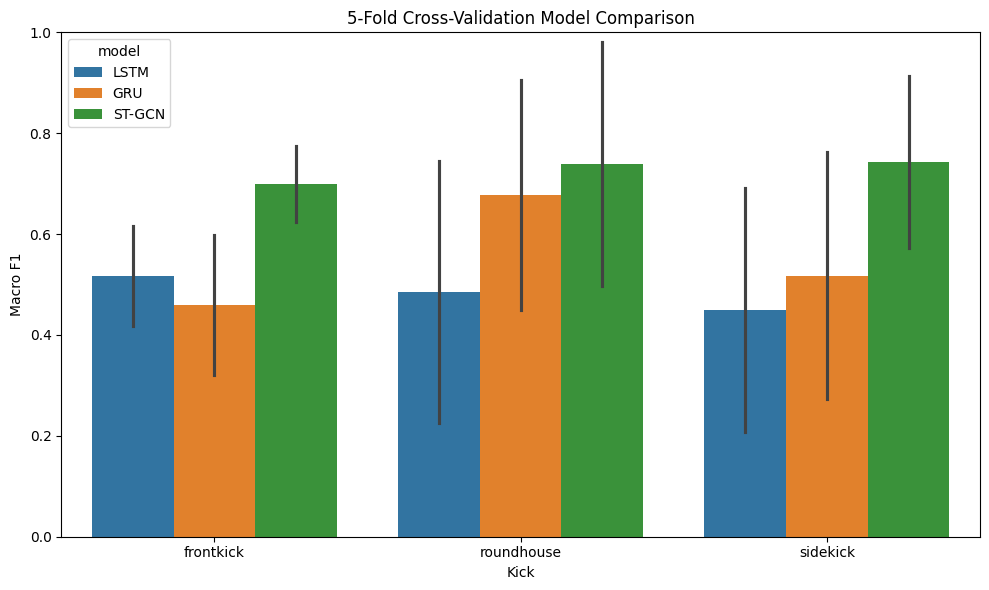

In [36]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=all_cv_results,
    x="kick",
    y="macro_f1",
    hue="model",
    errorbar="sd"
)

plt.ylabel("Macro F1")
plt.xlabel("Kick")
plt.title("5-Fold Cross-Validation Model Comparison")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

In [37]:
best_models = (
    all_cv_summary
    .sort_values(
        ["kick", "macro_f1_mean"],
        ascending=[True, False]
    )
    .groupby("kick")
    .first()
    .reset_index()
)

display(best_models)

,kick,model,accuracy_mean,accuracy_std,balanced_accuracy_mean,macro_f1_mean,macro_f1_std,weighted_f1_mean
0,frontkick,ST-GCN,0.756667,0.033884,0.762222,0.699333,0.074476,0.777963
1,roundhouse,ST-GCN,0.800000,0.139443,0.766667,0.738889,0.242097,0.777222
2,sidekick,ST-GCN,0.759444,0.137431,0.750000,0.743444,0.170310,0.753086


In [38]:
def train_final_model(kick,model_name,train_dev_manifest,epochs=50):
    kick_train = train_dev_manifest[train_dev_manifest["kick"] == kick].reset_index(drop=True)

    num_classes = len(MASTER_MAP[kick])

    augmented_train = expand_training_manifest(kick_train)

    train_mean, train_std = calculate_mean_std(augmented_train["path"].tolist())

    dataset = TaekwondoDataset(
        augmented_train,
        max_frames=MAX_FRAMES,
        mean=train_mean,
        std=train_std
    )

    loader = DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=2,
        pin_memory=True
    )


    model = build_model(model_name,num_classes).to(DEVICE)

    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.Adam(model.parameters(),lr=LEARNING_RATE,weight_decay=WEIGHT_DECAY)

    history = []
    for epoch in range(1,epochs + 1):
        loss, acc, macro_f1 = train_one_epoch(model,loader,criterion,optimizer)

        history.append({
            "epoch": epoch,
            "loss": loss,
            "accuracy": acc,
            "macro_f1": macro_f1
        })

        print(
            f"Epoch {epoch:02d} | "
            f"Loss {loss:.4f} | "
            f"Accuracy {acc:.3f} | "
            f"Macro F1 {macro_f1:.3f}"
        )

    return model,train_mean,train_std,pd.DataFrame(history)

In [39]:
def evaluate_on_test(kick,model,mean,std,test_manifest):

    test_df = test_manifest[test_manifest["kick"] == kick].copy()

    test_df["path"] = test_df["filename"].apply(lambda x: os.path.join(DATA_PATH,x))

    dataset = TaekwondoDataset(
        test_df,
        max_frames=MAX_FRAMES,
        mean=mean,
        std=std
    )

    loader = DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=2
    )

    criterion = nn.CrossEntropyLoss()

    loss, metrics, y_true, y_pred = evaluate(model,loader,criterion)

    return {
        "loss": loss,
        "metrics": metrics,
        "y_true": y_true,
        "y_pred": y_pred,
        "test_manifest": test_df
    }

In [40]:
def plot_confusion_matrix(y_true,y_pred,kick):
    class_names = list(MASTER_MAP[kick].keys())
    
    cm = confusion_matrix(y_true,y_pred)

    plt.figure(figsize=(8, 7))
    
    sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",xticklabels=class_names,yticklabels=class_names)

    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"{kick.capitalize()} - Test Confusion Matrix")
    plt.xticks(rotation=45,ha="right")
    plt.tight_layout()
    plt.show()

In [41]:
def print_test_report(kick,y_true,y_pred):

    class_names = list(MASTER_MAP[kick].keys())

    print(classification_report(y_true,y_pred,target_names=class_names,digits=4,zero_division=0))

################################################################################
FINAL MODEL: FRONTKICK → ST-GCN
################################################################################


100%|██████████| 12/12 [00:02<00:00,  5.59it/s]


Epoch 01 | Loss 1.5080 | Accuracy 0.311 | Macro F1 0.279


100%|██████████| 12/12 [00:02<00:00,  5.81it/s]


Epoch 02 | Loss 1.3302 | Accuracy 0.411 | Macro F1 0.352


...

100%|██████████| 12/12 [00:02<00:00,  5.62it/s]


Epoch 49 | Loss 0.1944 | Accuracy 0.928 | Macro F1 0.930


100%|██████████| 12/12 [00:02<00:00,  5.74it/s]

Epoch 50 | Loss 0.0663 | Accuracy 0.994 | Macro F1 0.993



FINAL TEST RESULTS
Accuracy:           0.7500
Balanced Accuracy:  0.7000
Macro Precision:    0.6500
Macro Recall:       0.7000
Macro F1:           0.6714
Weighted F1:        0.6964
                             precision    recall  f1-score   support

          frontkick_perfect     0.7500    1.0000    0.8571         3
frontkick_errorDroppedGuard     1.0000    1.0000    1.0000         1
 frontkick_errorLeaningBack     0.0000    0.0000    0.0000         1
   frontkick_errorNoChamber     1.0000    1.0000    1.0000         1
frontkick_errorNoRetraction     0.5000    0.5000    0.5000         2

                   accuracy                         0.7500         8
                  macro avg     0.6500    0.7000    0.6714         8
               weighted avg     0.6562    0.7500    0.6964         8



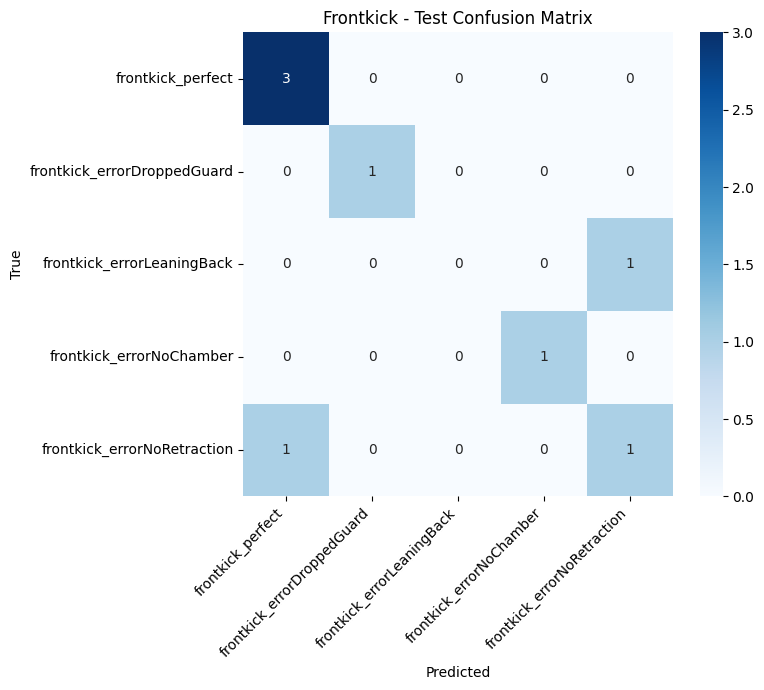

################################################################################
FINAL MODEL: ROUNDHOUSE → ST-GCN
################################################################################


100%|██████████| 8/8 [00:01<00:00,  5.63it/s]


Epoch 01 | Loss 1.0201 | Accuracy 0.543 | Macro F1 0.496


100%|██████████| 8/8 [00:01<00:00,  5.68it/s]


Epoch 02 | Loss 0.9642 | Accuracy 0.500 | Macro F1 0.415


...

100%|██████████| 8/8 [00:01<00:00,  5.67it/s]


Epoch 49 | Loss 0.0410 | Accuracy 0.983 | Macro F1 0.983


100%|██████████| 8/8 [00:01<00:00,  5.56it/s]

Epoch 50 | Loss 0.0271 | Accuracy 0.991 | Macro F1 0.991



FINAL TEST RESULTS
Accuracy:           0.8333
Balanced Accuracy:  0.8333
Macro Precision:    0.9167
Macro Recall:       0.8333
Macro F1:           0.8413
Weighted F1:        0.8175
                              precision    recall  f1-score   support

          roundhouse_perfect     0.7500    1.0000    0.8571         3
roundhouse_errorDroppedGuard     1.0000    0.5000    0.6667         2
 roundhouse_errorLazyChamber     1.0000    1.0000    1.0000         1

                    accuracy                         0.8333         6
                   macro avg     0.9167    0.8333    0.8413         6
                weighted avg     0.8750    0.8333    0.8175         6



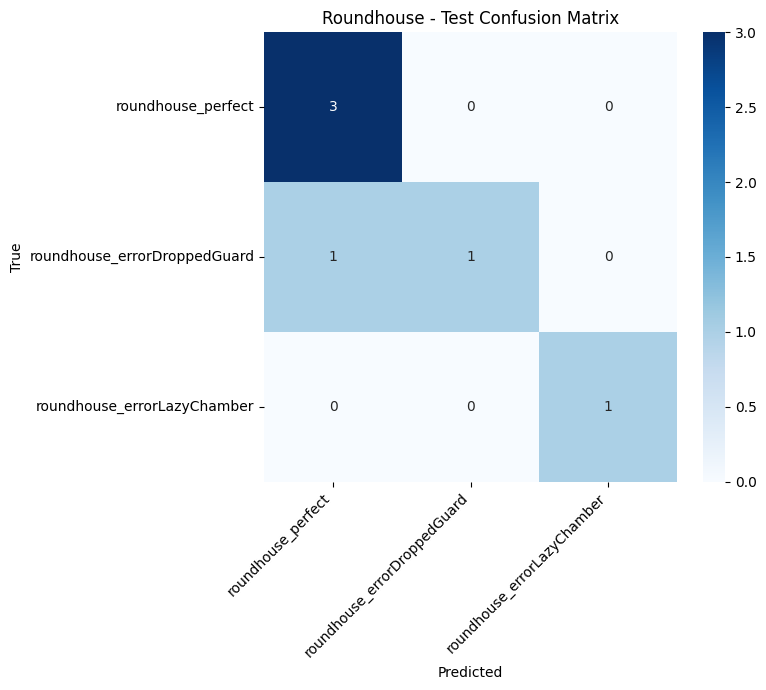

################################################################################
FINAL MODEL: SIDEKICK → ST-GCN
################################################################################


100%|██████████| 12/12 [00:01<00:00,  6.20it/s]


Epoch 01 | Loss 1.5618 | Accuracy 0.350 | Macro F1 0.268


100%|██████████| 12/12 [00:02<00:00,  5.87it/s]


Epoch 02 | Loss 1.4568 | Accuracy 0.361 | Macro F1 0.292


...

100%|██████████| 12/12 [00:02<00:00,  5.92it/s]


Epoch 49 | Loss 0.1237 | Accuracy 0.961 | Macro F1 0.961


100%|██████████| 12/12 [00:02<00:00,  5.74it/s]

Epoch 50 | Loss 0.2072 | Accuracy 0.928 | Macro F1 0.925



FINAL TEST RESULTS
Accuracy:           0.7778
Balanced Accuracy:  0.7000
Macro Precision:    0.7000
Macro Recall:       0.7000
Macro F1:           0.7000
Weighted F1:        0.7778
                              precision    recall  f1-score   support

            sidekick_perfect     1.0000    1.0000    1.0000         3
  sidekick_errorDroppedGuard     0.5000    0.5000    0.5000         2
sidekick_errorFootPointingUp     1.0000    1.0000    1.0000         1
       sidekick_errorNoPivot     1.0000    1.0000    1.0000         2
    sidekick_errorOffBalance     0.0000    0.0000    0.0000         1

                    accuracy                         0.7778         9
                   macro avg     0.7000    0.7000    0.7000         9
                weighted avg     0.7778    0.7778    0.7778         9



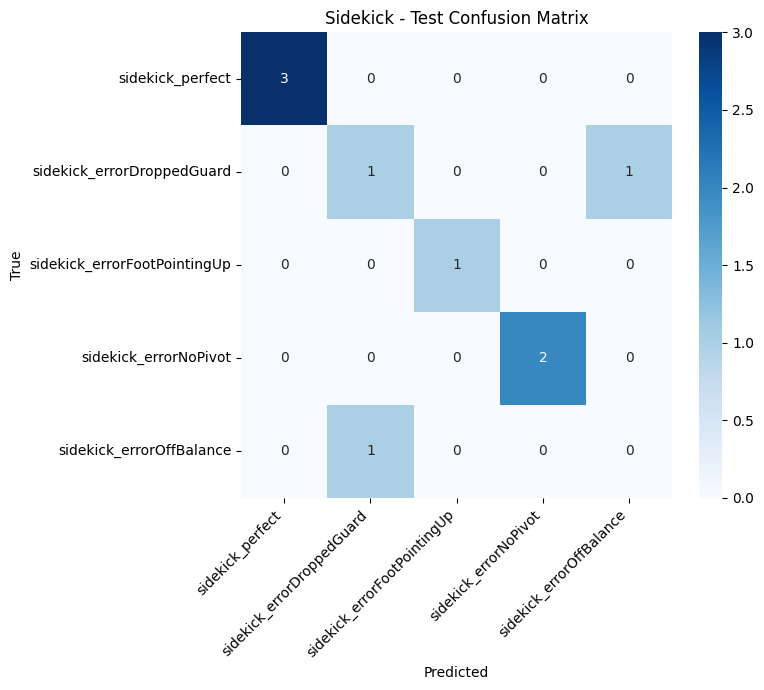

In [42]:
final_models = {}
final_results = {}

for kick in ["frontkick","roundhouse","sidekick"]:
    best_row = all_cv_summary[all_cv_summary["kick"] == kick].sort_values("macro_f1_mean",ascending=False).iloc[0]

    best_model_name = best_row["model"]

    print("#" * 80)
    print(
        f"FINAL MODEL: "
        f"{kick.upper()} → {best_model_name}"
    )
    print("#" * 80)

    model, mean, std, history = train_final_model(
        kick=kick,
        model_name=best_model_name,
        train_dev_manifest=train_dev_manifest,
        epochs=EPOCHS
    )

    test_result = evaluate_on_test(
        kick=kick,
        model=model,
        mean=mean,
        std=std,
        test_manifest=test_manifest
    )

    final_models[kick] = {
        "model": model,
        "model_name": best_model_name,
        "mean": mean,
        "std": std,
        "history": history
    }

    final_results[kick] = test_result

    print("\nFINAL TEST RESULTS")

    metrics = test_result["metrics"]

    print(
        f"Accuracy:           "
        f"{metrics['accuracy']:.4f}"
    )

    print(
        f"Balanced Accuracy:  "
        f"{metrics['balanced_accuracy']:.4f}"
    )

    print(
        f"Macro Precision:    "
        f"{metrics['macro_precision']:.4f}"
    )

    print(
        f"Macro Recall:       "
        f"{metrics['macro_recall']:.4f}"
    )

    print(
        f"Macro F1:           "
        f"{metrics['macro_f1']:.4f}"
    )

    print(
        f"Weighted F1:        "
        f"{metrics['weighted_f1']:.4f}"
    )

    print_test_report(
        kick,
        test_result["y_true"],
        test_result["y_pred"]
    )

    plot_confusion_matrix(
        test_result["y_true"],
        test_result["y_pred"],
        kick
    )

In [43]:
os.makedirs(
    "/kaggle/working/weights",
    exist_ok=True
)


for kick, info in final_models.items():

    checkpoint = {

        "kick": kick,

        "model_name": info["model_name"],

        "model_state_dict":
            info["model"].state_dict(),

        "mean":
            info["mean"].tolist(),

        "std":
            info["std"].tolist(),

        "max_frames":
            MAX_FRAMES,

        "feature_columns":
            FEATURE_COLUMNS,

        "node_features":
            NODE_FEATURES,

        "median_kernel":
            5,

        "one_euro": {
            "min_cutoff": 0.8,
            "beta": 0.05,
            "d_cutoff": 1.0
        }
    }

    path = (
        f"/kaggle/working/weights/"
        f"{kick}_{info['model_name']}.pth"
    )

    torch.save(
        checkpoint,
        path
    )

    print("Saved:", path)

Saved: /kaggle/working/weights/frontkick_ST-GCN.pth
Saved: /kaggle/working/weights/roundhouse_ST-GCN.pth
Saved: /kaggle/working/weights/sidekick_ST-GCN.pth


======================================================================================================

In [44]:
# from scipy.interpolate import interp1d

# class DataAugment:
#     def __init__(self):
#         # 0: base_knee, 1: base_pivot, 2: chamber, 3: foot_angle, 4: spine
#         self.angle_indices = [0, 1, 2, 3, 4]
        
#         # 'guard_dropped' (boolean 0.0 or 1.0)
#         self.boolean_index = 7

#     def add_gaussian_noise(self, sequence, mean=0.0, std=2.0):
#         """
#         Adds random jitter ONLY to the angle columns to simulate bad camera tracking.
#         """
#         noisy_sequence = np.copy(sequence)
#         noise = np.random.normal(loc=mean, scale=std, size=(sequence.shape[0], len(self.angle_indices)))
        
#         noisy_sequence[:, self.angle_indices] += noise
#         return noisy_sequence

#     def temporal_warp(self, sequence, min_speed=0.7, max_speed=1.3):
#         """
#         Simulates different kicking tempos by stretching or compressing the time series.
#         """
#         num_frames = sequence.shape[0]
#         speed_factor = np.random.uniform(low=min_speed, high=max_speed)
#         new_num_frames = max(12, int(num_frames / speed_factor)) 
        
#         original_timesteps = np.linspace(0, 1, num_frames)
#         new_timesteps = np.linspace(0, 1, new_num_frames)
        
#         interpolator = interp1d(original_timesteps, sequence, axis=0, kind='linear')
#         warped_sequence = interpolator(new_timesteps)
        
#         warped_sequence[:, self.boolean_index] = np.clip(np.round(warped_sequence[:, self.boolean_index]), 0, 1)
#         return warped_sequence
    
#     def augment_pipeline(self, sequence):
#         """
#         Returns a dictionary of variations so we can name the output files correctly.
#         """
#         variations = {}
#         variations['original'] = sequence
#         variations['noisy'] = self.add_gaussian_noise(sequence)
#         variations['warped'] = self.temporal_warp(sequence)
#         variations['noisy_warped'] = self.add_gaussian_noise(self.temporal_warp(sequence))
#         return variations


# def run_batch_augmentation(input_dir, output_dir):
#     os.makedirs(output_dir, exist_ok=True)

#     csv_files = [f for f in os.listdir(input_dir) if f.endswith('.csv')]
#     if not csv_files:
#         print(f"No CSVs found in {input_dir}.")
#         return
        
#     print(f"Found {len(csv_files)} base CSVs.")
    
#     augmenter = DataAugment()
#     total_generated = 0
    
#     for file in csv_files:
#         path = os.path.join(input_dir, file)
#         df = pd.read_csv(path)
#         df_clean = clean_sequence(df)
#         columns = df_clean.columns
#         sequence = df_clean.values 
        
#         augmentations = augmenter.augment_pipeline(sequence)
#         base_filename = file.replace(".csv", "")
        
#         for suffix, aug_seq in augmentations.items():
#             aug_df = pd.DataFrame(aug_seq, columns=columns)
#             new_filename = f"{base_filename}_{suffix}.csv"
            
#             aug_df.to_csv(os.path.join(output_dir, new_filename), index=False)
#             total_generated += 1
            
#     print("Data Augmentation Complete!")
#     print(f"Original Videos: {len(csv_files)}")
#     print(f"Total Training Files Generated: {total_generated}")
#     print(f"Saved to: {output_dir}")
# run_batch_augmentation(input_dir=r"D:\Github\TAEKWONDO-AI-COACH\data\extracted_csvs", output_dir=r"D:\Github\TAEKWONDO-AI-COACH\data\augmented_csvs")